In [7]:
import numpy as np

def simulate_system(lambda_val, mu_val, tw_max, T_total):
    time = 0
    ts_prev = 0  # Время окончания обслуживания предыдущей заявки

    processed_count = 0
    lost_count = 0
    total_wait_time = 0
    busy_time = 0

    current_time = 0
    while True:
        # Генерируем время до следующей заявки (экспоненциальное)
        interarrival = np.random.exponential(1/lambda_val)
        current_time += interarrival

        # Прерываем, если вышли за пределы времени моделирования
        if current_time >= T_total:
            break

        # Генерируем допустимое время ожидания (равномерное [0, tw_max])
        # Если tw_max = 0, то время ожидания строго 0
        dtw = np.random.uniform(0, tw_max) if tw_max > 0 else 0

        # Длительность обслуживания (экспоненциальное)
        service_duration = np.random.exponential(1/mu_val)

        # Логика событий (согласно рис 4.1 - 4.3)
        if current_time + dtw < ts_prev:
            # Заявка не дождалась и получила отказ
            lost_count += 1
        else:
            # Начало обслуживания
            start_service = max(current_time, ts_prev)
            wait_time = start_service - current_time
            total_wait_time += wait_time

            busy_time += service_duration
            ts_prev = start_service + service_duration
            processed_count += 1

    total_calls = processed_count + lost_count

    # Расчет выходных характеристик по Заданию 1
    prob_process = processed_count / total_calls if total_calls > 0 else 0
    prob_reject = lost_count / total_calls if total_calls > 0 else 0
    idle_time = max(0, T_total - busy_time)
    avg_wait = total_wait_time / processed_count if processed_count > 0 else 0
    load_factor = busy_time / T_total

    return {
        "processed": processed_count,             # число обработанных заявок
        "lost": lost_count,                       # число отказов
        "prob_process": prob_process,             # вероятность обработки заявки
        "prob_reject": prob_reject,               # вероятность отказа
        "idle_time": idle_time,                   # время простоя
        "total_wait_time": total_wait_time,       # суммарное время ожидания
        "avg_wait": avg_wait,                     # среднее время ожидания в очереди
        "load": load_factor                       # вероятность загрузки (коэф. загрузки)
    }

In [8]:
# Используем функцию simulate_system из Задания 1

# Заданные параметры
mu_val = 0.8
tw_max = 1.0
lambda_val = 0.7
T_total = 1000

# Запуск моделирования
np.random.seed(42) # Фиксируем seed для воспроизводимости (опционально)
results = simulate_system(lambda_val, mu_val, tw_max, T_total)

# Вывод результатов
print("=== Результаты моделирования (Задание 2) ===")
print(f"Число обработанных заявок: {results['processed']}")
print(f"Число отказов: {results['lost']}")
print(f"Вероятность обработки заявки: {results['prob_process']:.4f}")
print(f"Вероятность отказа: {results['prob_reject']:.4f}")
print(f"Время простоя устройства: {results['idle_time']:.2f} сек")
print(f"Суммарное время ожидания заявок: {results['total_wait_time']:.2f} сек")
print(f"Среднее время ожидания заявки: {results['avg_wait']:.4f} сек")
print(f"Вероятность загрузки (коэфф. использования): {results['load']:.4f}")

=== Результаты моделирования (Задание 2) ===
Число обработанных заявок: 417
Число отказов: 273
Вероятность обработки заявки: 0.6043
Вероятность отказа: 0.3957
Время простоя устройства: 454.52 сек
Суммарное время ожидания заявок: 39.77 сек
Среднее время ожидания заявки: 0.0954 сек
Вероятность загрузки (коэфф. использования): 0.5455


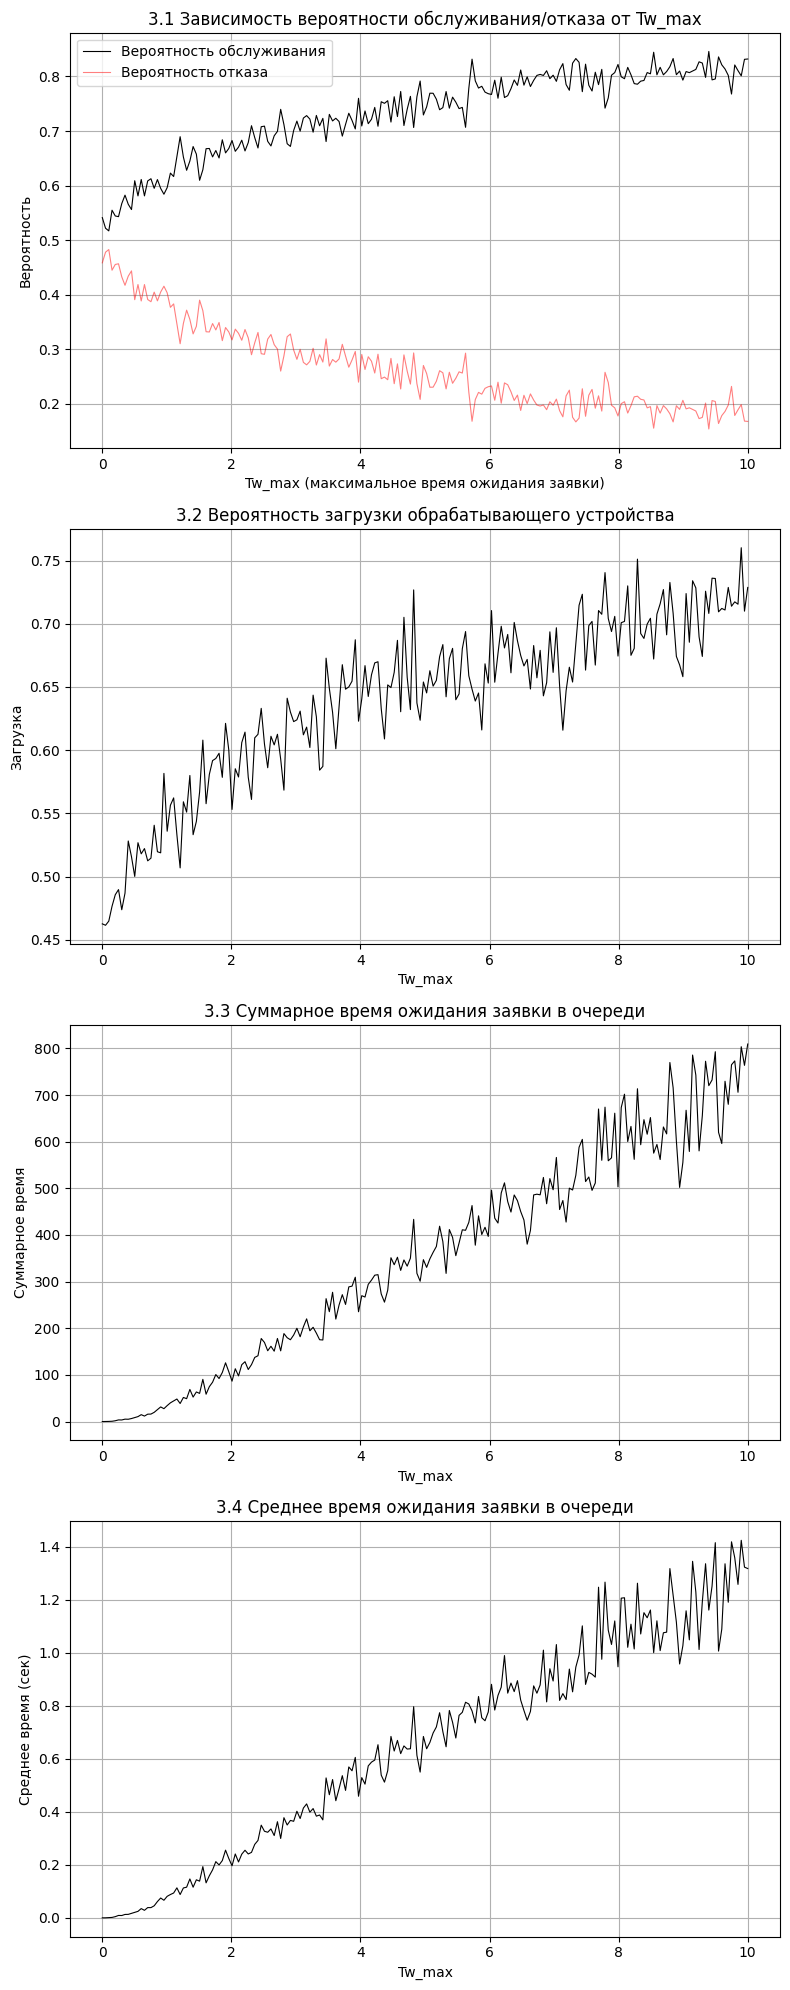

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# Используем функцию simulate_system из Задания 1

# Параметры системы
lambda_val = 0.7
mu_val = 0.8
T_total = 1000

# Диапазон Tw_max от 0 до 10 (как на графиках в методичке)
tw_values = np.linspace(0, 10, 200)

prob_processes = []
prob_rejects = []
loads = []
total_waits = []
avg_waits = []

# Сбор статистики
for tw in tw_values:
    res = simulate_system(lambda_val, mu_val, tw, T_total)
    prob_processes.append(res["prob_process"])
    prob_rejects.append(res["prob_reject"])
    loads.append(res["load"])
    total_waits.append(res["total_wait_time"])
    avg_waits.append(res["avg_wait"])

# Построение графиков
fig, axs = plt.subplots(4, 1, figsize=(8, 20))

# 3.1 Вероятность обслуживания и отказа
axs[0].plot(tw_values, prob_processes, label='Вероятность обслуживания', color='black', linewidth=0.8)
axs[0].plot(tw_values, prob_rejects, label='Вероятность отказа', color='red', linewidth=0.8, alpha=0.5)
axs[0].set_title('3.1 Зависимость вероятности обслуживания/отказа от Tw_max')
axs[0].set_xlabel('Tw_max (максимальное время ожидания заявки)')
axs[0].set_ylabel('Вероятность')
axs[0].grid(True)
axs[0].legend()

# 3.2 Вероятность загрузки обрабатывающего устройства
axs[1].plot(tw_values, loads, color='black', linewidth=0.8)
axs[1].set_title('3.2 Вероятность загрузки обрабатывающего устройства')
axs[1].set_xlabel('Tw_max')
axs[1].set_ylabel('Загрузка')
axs[1].grid(True)

# 3.3 Суммарное время ожидания
axs[2].plot(tw_values, total_waits, color='black', linewidth=0.8)
axs[2].set_title('3.3 Суммарное время ожидания заявки в очереди')
axs[2].set_xlabel('Tw_max')
axs[2].set_ylabel('Суммарное время')
axs[2].grid(True)

# 3.4 Среднее время ожидания
axs[3].plot(tw_values, avg_waits, color='black', linewidth=0.8)
axs[3].set_title('3.4 Среднее время ожидания заявки в очереди')
axs[3].set_xlabel('Tw_max')
axs[3].set_ylabel('Среднее время (сек)')
axs[3].grid(True)

plt.tight_layout()
plt.show()

In [10]:
import numpy as np

# Используем функцию simulate_system из Задания 1

lambda_val = 0.7
mu_val = 0.8
T_total = 2000 # Увеличим время для более стабильных результатов
num_runs = 20  # Количество прогонов для усреднения шума

tw_candidates = np.linspace(0.1, 3.0, 300) # Ищем в узком диапазоне с малым шагом

optimal_tw = None
valid_tws = []

print("=== Поиск оптимального Tw_max (Задание 4) ===")

for tw in tw_candidates:
    avg_prob = 0
    avg_load = 0
    avg_wait = 0

    # Усредняем результаты для устранения случайных выбросов
    for _ in range(num_runs):
        res = simulate_system(lambda_val, mu_val, tw, T_total)
        avg_prob += res["prob_process"]
        avg_load += res["load"]
        avg_wait += res["avg_wait"]

    avg_prob /= num_runs
    avg_load /= num_runs
    avg_wait /= num_runs

    # Проверка условий из методички
    cond1 = avg_prob >= 0.80
    cond2 = avg_load >= 0.60
    cond3 = avg_wait <= 0.35

    if cond1 and cond2 and cond3:
        valid_tws.append((tw, avg_prob, avg_load, avg_wait))

if valid_tws:
    # Оптимальным можно считать максимальное Tw из разрешенных,
    # так как оно максимизирует загрузку и вероятность обработки,
    # не нарушая ограничение по среднему времени ожидания.
    optimal_tw_data = valid_tws[-1]

    print(f"\nНайдены подходящие значения Tw_max в диапазоне от {valid_tws[0][0]:.3f} до {valid_tws[-1][0]:.3f}")
    print(f"\nРекомендуемое оптимальное значение Tw_max: {optimal_tw_data[0]:.3f} сек")
    print("При этом значении в среднем выполняются условия:")
    print(f"1. Вероятность обработки: {optimal_tw_data[1]:.4f} (Требуется >= 0.8)")
    print(f"2. Вероятность загрузки:  {optimal_tw_data[2]:.4f} (Требуется >= 0.6)")
    print(f"3. Ср. время ожидания:    {optimal_tw_data[3]:.4f} (Требуется <= 0.35)")

    print("\nОбоснование:")
    print("Данное значение Tw_max выбрано потому, что оно удовлетворяет всем жестким ограничениям")
    print("ТЗ одновременно. Мы берем верхнюю границу подходящего диапазона, так как увеличение")
    print("допустимого времени ожидания повышает вероятность обработки заявок и загрузку системы,")
    print("но мы останавливаемся на границе, где среднее время ожидания достигает критических 0.35 с.")
else:
    print("Не найдено значения Tw_max, удовлетворяющего всем условиям одновременно.")
    print("Возможно, требуется изменить интенсивности потока (лямбда) или обслуживания (мю).")

=== Поиск оптимального Tw_max (Задание 4) ===
Не найдено значения Tw_max, удовлетворяющего всем условиям одновременно.
Возможно, требуется изменить интенсивности потока (лямбда) или обслуживания (мю).
